# Pretrained Model Linear Pruning Experiments (IEEE-Style Figures)

This notebook loads all available pretrained models, runs linear/magnitude pruning on each model in separate experiment cells, and plots NMSE versus pruning percentage in a publication-ready format.

In [1]:
# Imports and plotting defaults
import os
import numpy as np
import matplotlib.pyplot as plt

from sparseDPD import DataManager
from sparseDPD import LinearExperiment
from sparseDPD import ARVTDNN_NeuralNetwork
from sparseDPD import PNTDNN_NeuralNetwork
from sparseDPD import PGJANET_NeuralNetwork

# IEEE-style plotting defaults
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'legend.fontsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'lines.linewidth': 1.6,
    'lines.markersize': 4,
    'figure.dpi': 160,
    'savefig.dpi': 300
})

print('Imports loaded.')

Imports loaded.


In [2]:
# Load dataset
data_manager = DataManager(
    filepath='UCD_datasets/PA_IO.mat',
    num_training_points=19000,
    num_validaiton_points=1000,
    num_test_points=2000
)

training_dataset = data_manager.training_dataset
validation_dataset = data_manager.validation_dataset
test_dataset = data_manager.test_dataset

print('Dataset ready.')

Dataset ready.


In [7]:
# Load all pretrained models
models = {}

models['ARVTDNN_OneLayer'] = ARVTDNN_NeuralNetwork(
    num_memory_levels=15,
    forward_model=True,
    model_type='OneLayerNetwork',
    nn_file_path='pre_trained_models/arvtdnn_one_layer.pt'
)

# Keep PGJANET configuration aligned with the baseline training notebook.
models['PGJANET'] = PGJANET_NeuralNetwork(
    num_memory_levels=30,
    model_type='PGJANETNetwork',
    forward_model=True,
    seq_stride=10,
    batch_size=32,
    hidden_size=32,
    nn_file_path='pre_trained_models/pgjanet_checkpoint.pt'
)

models['PNTDNN_OneLayer'] = PNTDNN_NeuralNetwork(
    num_memory_levels=15,
    forward_model=True,
    model_type='OneLayerNetwork',
    nn_file_path='pre_trained_models/pntdnn_one_layer.pt'
)

models['PNTDNN_ThreeLayer'] = PNTDNN_NeuralNetwork(
    num_memory_levels=15,
    forward_model=True,
    model_type='ThreeLayerNetwork',
    nn_file_path='pre_trained_models/pntdnn_three_layer.pt'
)

print('Loaded models:', ', '.join(models.keys()))

Using cuda device
Using cuda device
Using cuda device
Using cuda device
Loaded models: ARVTDNN_OneLayer, PGJANET, PNTDNN_OneLayer, PNTDNN_ThreeLayer


In [4]:
# Common pruning settings and result storage
num_prune_iterations = 12
prune_amount = 0.2

# PGJANET converges faster, so use fewer retraining epochs than other models.
default_retrain_epochs = 100
model_retrain_epochs = {
    'PGJANET': 35
}

linear_pruning_results = {}

def run_linear_pruning_experiment(model_name):
    retrain_epochs = model_retrain_epochs.get(model_name, default_retrain_epochs)

    exp = LinearExperiment(
        nn_model=models[model_name],
        num_prune_iterations=num_prune_iterations,
        prune_amount=prune_amount,
        retrain_epochs=retrain_epochs,
        training_dataset=training_dataset,
        valid_dataset=validation_dataset,
        test_dataset=test_dataset
    )

    baseline_nmse = exp.original_nn_model.calculate_forward_nmse(exp.test_dataset)
    baseline_params = exp.original_nn_model.get_num_params()

    prune_pcts, nmse_results, valid_losses, best_epochs, all_valid_losses = exp.prune()

    linear_pruning_results[model_name] = {
        'baseline_nmse': baseline_nmse,
        'baseline_params': baseline_params,
        'retrain_epochs': retrain_epochs,
        'prune_pcts': [0.0] + prune_pcts,
        'nmse': [baseline_nmse] + nmse_results,
        'valid_losses': all_valid_losses,
        'best_epochs': best_epochs
    }

    print(f"{model_name}: retrain_epochs={retrain_epochs}")
    print(f"{model_name}: baseline NMSE={baseline_nmse:.2f} dB, params={baseline_params:,}")
    print(f"{model_name}: final pruning={linear_pruning_results[model_name]['prune_pcts'][-1]:.2f}%")

## Linear Pruning Experiments (One Cell per Model)

In [5]:
# Experiment 1: ARVTDNN_OneLayer
run_linear_pruning_experiment('ARVTDNN_OneLayer')


Pruning Iteration 1/12
Pruning 20.0% of remaining weights...
Current pruning: 20.00% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=6.2174e-01  Valid Loss=3.8334e-02  LR=1.00e-03  NMSE=-33.6449 dB
Epoch  20/100  Loss=3.4457e-01  Valid Loss=2.1457e-02  LR=5.00e-04  NMSE=-36.1649 dB
Epoch  30/100  Loss=2.6352e-01  Valid Loss=1.6772e-02  LR=2.50e-04  NMSE=-37.2350 dB
Epoch  40/100  Loss=2.1121e-01  Valid Loss=1.3859e-02  LR=1.25e-04  NMSE=-38.0635 dB
Epoch  50/100  Loss=2.0913e-01  Valid Loss=1.3791e-02  LR=1.25e-04  NMSE=-38.0847 dB
Epoch  60/100  Loss=1.9062e-01  Valid Loss=1.3230e-02  LR=6.25e-05  NMSE=-38.2649 dB
Epoch  70/100  Loss=1.8735e-01  Valid Loss=1.3343e-02  LR=6.25e-05  NMSE=-38.2282 dB
Epoch  80/100  Loss=1.7939e-01  Valid Loss=1.3054e-02  LR=3.13e-05  NMSE=-38.3231 dB
Epoch  90/100  Loss=1.7403e-01  Valid Loss=1.2965e-02  LR=1.56e-05  NMSE=-38.3531 dB
Epoch 100/100  Loss=1.7388e-01  Valid Loss=1.2854e-02  LR=1.56e-05  NMSE=-38.3903 dB

Best model fro

In [8]:
# Experiment 2: PGJANET
run_linear_pruning_experiment('PGJANET')


Pruning Iteration 1/12
Pruning 20.0% of remaining weights...
Current pruning: 20.01% of weights are zero
Retraining for 35 epochs...
Epoch  10/35  Loss=1.2689e-01  Valid Loss=8.4603e-03  LR=1.00e-03  NMSE=-40.0861 dB
Epoch  20/35  Loss=1.2461e-01  Valid Loss=6.0807e-03  LR=1.00e-03  NMSE=-41.5203 dB
Epoch  30/35  Loss=1.0526e-01  Valid Loss=5.9565e-03  LR=5.00e-04  NMSE=-41.6100 dB

Best model from epoch 33 with validation loss: 5.6543e-03
NMSE: -41.5868 dB

Pruning Iteration 2/12
Pruning 20.0% of remaining weights...
Current pruning: 36.00% of weights are zero
Retraining for 35 epochs...
Epoch  10/35  Loss=1.2279e-01  Valid Loss=7.6173e-03  LR=1.00e-03  NMSE=-40.5419 dB
Epoch  20/35  Loss=1.1463e-01  Valid Loss=6.1391e-03  LR=1.00e-03  NMSE=-41.4789 dB
Epoch  30/35  Loss=1.0136e-01  Valid Loss=5.5821e-03  LR=5.00e-04  NMSE=-41.8919 dB

Best model from epoch 30 with validation loss: 5.5821e-03
NMSE: -41.7991 dB

Pruning Iteration 3/12
Pruning 20.0% of remaining weights...
Current prun

In [9]:
# Experiment 3: PNTDNN_OneLayer
run_linear_pruning_experiment('PNTDNN_OneLayer')


Pruning Iteration 1/12
Pruning 20.0% of remaining weights...
Current pruning: 20.00% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=2.6127e-01  Valid Loss=1.5915e-02  LR=1.00e-03  NMSE=-37.4627 dB
Epoch  20/100  Loss=2.1380e-01  Valid Loss=1.1067e-02  LR=5.00e-04  NMSE=-39.0404 dB
Epoch  30/100  Loss=1.7422e-01  Valid Loss=8.5110e-03  LR=2.50e-04  NMSE=-40.1809 dB
Epoch  40/100  Loss=1.6109e-01  Valid Loss=7.8969e-03  LR=1.25e-04  NMSE=-40.5061 dB
Epoch  50/100  Loss=1.6340e-01  Valid Loss=7.9209e-03  LR=1.25e-04  NMSE=-40.4929 dB
Epoch  60/100  Loss=1.5911e-01  Valid Loss=7.9674e-03  LR=6.25e-05  NMSE=-40.4675 dB
Epoch  70/100  Loss=1.5588e-01  Valid Loss=7.7996e-03  LR=3.13e-05  NMSE=-40.5600 dB
Epoch  80/100  Loss=1.5616e-01  Valid Loss=7.7976e-03  LR=3.13e-05  NMSE=-40.5611 dB
Epoch  90/100  Loss=1.5622e-01  Valid Loss=7.7959e-03  LR=3.13e-05  NMSE=-40.5620 dB
Epoch 100/100  Loss=1.5614e-01  Valid Loss=7.7914e-03  LR=3.13e-05  NMSE=-40.5645 dB

Best model fro

In [10]:
# Experiment 4: PNTDNN_ThreeLayer
run_linear_pruning_experiment('PNTDNN_ThreeLayer')


Pruning Iteration 1/12
Pruning 20.0% of remaining weights...
Current pruning: 20.00% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=3.0245e-01  Valid Loss=2.2956e-02  LR=1.00e-03  NMSE=-35.8718 dB
Epoch  20/100  Loss=1.8965e-01  Valid Loss=1.1221e-02  LR=5.00e-04  NMSE=-38.9802 dB
Epoch  30/100  Loss=1.7442e-01  Valid Loss=7.9087e-03  LR=2.50e-04  NMSE=-40.4996 dB
Epoch  40/100  Loss=1.7839e-01  Valid Loss=8.2280e-03  LR=1.25e-04  NMSE=-40.3277 dB
Epoch  50/100  Loss=1.5787e-01  Valid Loss=7.8622e-03  LR=1.25e-04  NMSE=-40.5252 dB
Epoch  60/100  Loss=1.5037e-01  Valid Loss=7.7107e-03  LR=6.25e-05  NMSE=-40.6097 dB
Epoch  70/100  Loss=1.5065e-01  Valid Loss=7.6647e-03  LR=6.25e-05  NMSE=-40.6357 dB
Epoch  80/100  Loss=1.5081e-01  Valid Loss=7.6433e-03  LR=6.25e-05  NMSE=-40.6479 dB
Epoch  90/100  Loss=1.5076e-01  Valid Loss=7.6301e-03  LR=6.25e-05  NMSE=-40.6554 dB
Epoch 100/100  Loss=1.5058e-01  Valid Loss=7.6184e-03  LR=6.25e-05  NMSE=-40.6620 dB

Best model fro

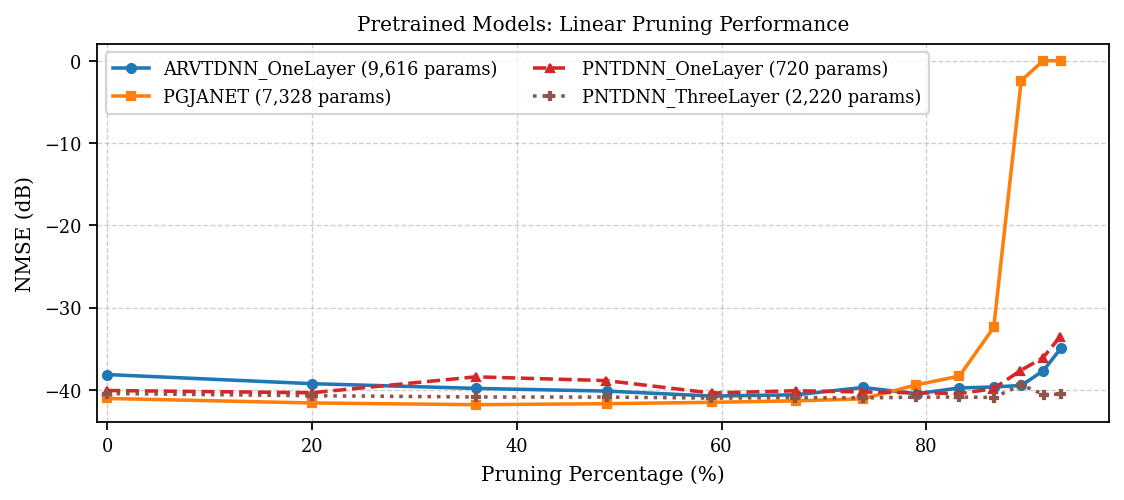

In [11]:
# IEEE-style summary figure: NMSE vs Pruning Percentage
fig, ax = plt.subplots(figsize=(7.1, 3.2))  # Two-column friendly

style_map = {
    'ARVTDNN_OneLayer': {'marker': 'o', 'linestyle': '-', 'color': '#1f77b4'},
    'PGJANET': {'marker': 's', 'linestyle': '-', 'color': '#ff7f0e'},
    'PNTDNN_OneLayer': {'marker': '^', 'linestyle': '--', 'color': '#d62728'},
    'PNTDNN_ThreeLayer': {'marker': 'P', 'linestyle': ':', 'color': '#8c564b'}
}

for model_name, result in linear_pruning_results.items():
    prune_pct = result['prune_pcts']
    nmse = result['nmse']
    base_params = result['baseline_params']

    style = style_map.get(model_name, {'marker': 'o', 'linestyle': '-', 'color': 'black'})
    label = f"{model_name} ({base_params:,} params)"

    ax.plot(
        prune_pct,
        nmse,
        marker=style['marker'],
        linestyle=style['linestyle'],
        color=style['color'],
        label=label
    )

ax.set_xlabel('Pruning Percentage (%)')
ax.set_ylabel('NMSE (dB)')
ax.set_title('Pretrained Models: Linear Pruning Performance')
ax.grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.6)
ax.set_xlim(left=-1)
ax.legend(loc='best', ncol=2, frameon=True)

plt.tight_layout()
plt.show()

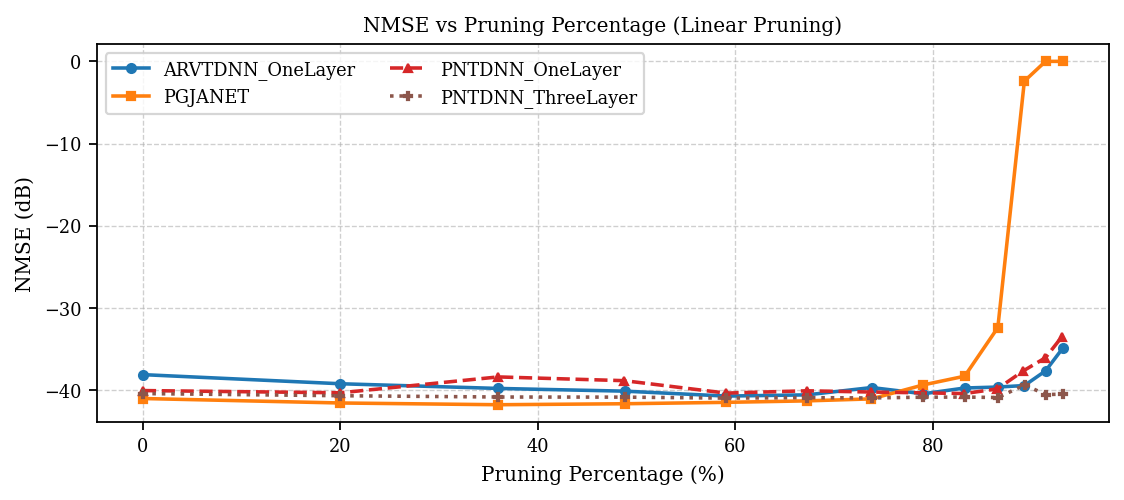

Saved figure: pretrained_linear_pruning_ieee.png


In [12]:
# Optional: Save high-resolution figure for paper usage
fig, ax = plt.subplots(figsize=(7.1, 3.2))

for model_name, result in linear_pruning_results.items():
    style = style_map.get(model_name, {'marker': 'o', 'linestyle': '-', 'color': 'black'})
    ax.plot(
        result['prune_pcts'],
        result['nmse'],
        marker=style['marker'],
        linestyle=style['linestyle'],
        color=style['color'],
        label=model_name
    )

ax.set_xlabel('Pruning Percentage (%)')
ax.set_ylabel('NMSE (dB)')
ax.set_title('NMSE vs Pruning Percentage (Linear Pruning)')
ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
ax.legend(loc='best', ncol=2, frameon=True)

plt.tight_layout()
output_path = 'pretrained_linear_pruning_ieee.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved figure: {output_path}')